# Viewing Results from Simulation Runs

This notebook provides a few example functions to view and interact with the images generated from the [CT_dataset_pipeline.py](../CT_dataset_pipeline.py).

To begin, locate the `metadata.csv` output by the simulation run specified by the `base_dir` variable in [CT_dataset_pipeline.py](../CT_dataset_pipeline.py), using Pandas this metadata file enables quickly filtering and working with the images to select the examples of interest.

In [34]:
!ls /gpfs_projects/brandon.nelson/pedsilicoICH/2024-09-20_shortscans/

case_000  case_002  case_004  case_006	case_008  case_010  case_012
case_001  case_003  case_005  case_007	case_009  case_011


In [35]:
from pathlib import Path

import pandas as pd
import numpy as np

base_dir = Path('/gpfs_projects/brandon.nelson/pedsilicoICH/2024-09-20_shortscans/')
metadata = pd.concat([pd.read_csv(o) for o in base_dir.rglob('*.csv')], ignore_index=True)
# metadata['lesion type'] = metadata['lesion type'].apply(lambda x: x.split("['")[-1].split("']")[0])
# metadata['contrast'] = metadata['contrast'].apply(lambda x: x.split('(')[-1].split(')')[0]).astype(int)
metadata

,name,age,contrast,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file
0,case_004,6.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,140,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
1,case_004,6.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,140,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
2,case_004,6.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,140,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
3,case_004,6.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,140,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
4,case_004,6.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,140,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,case_009,9.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,90,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,NaN
1900,case_009,9.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,90,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,NaN
1901,case_009,9.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,90,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,NaN
1902,case_009,9.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,90,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,NaN


In [36]:
metadata[~metadata.name.duplicated()]

,name,age,contrast,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file
0,case_004,6.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,140,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
154,case_007,6.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,100,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
308,case_008,10.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,100,110,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,NaN
455,case_001,12.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,100,110,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,NaN
616,case_010,6.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
770,case_002,11.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
931,case_005,10.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,140,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
1078,case_011,38.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,80,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
1295,case_000,12.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,250,70,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
1456,case_003,6.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,150,70,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...


In [37]:
metadata[metadata.name=='case_004']['lesion volume [mL]'].sum()

np.float64(2.04483512789011)

In [38]:
metadata[metadata.name=='case_001']['lesion volume [mL]'].sum()

np.float64(0.0)

In [46]:
metadata[(metadata['lesion volume [mL]']>0)]

,name,age,contrast,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file
36,case_004,6.5,[np.int64(165)],281.0,408.0,39.0,['subdural'],True,0.039348,300,140,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
37,case_004,6.5,[np.int64(165)],281.0,408.0,39.0,['subdural'],True,0.234577,300,140,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
38,case_004,6.5,[np.int64(165)],281.0,408.0,39.0,['subdural'],True,0.591972,300,140,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
39,case_004,6.5,[np.int64(165)],281.0,408.0,39.0,['subdural'],True,0.623288,300,140,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
40,case_004,6.5,[np.int64(165)],281.0,408.0,39.0,['subdural'],True,0.252156,300,140,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1738,case_006,9.0,[np.int64(104)],274.0,206.0,128.0,['epidural'],False,0.804430,50,70,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
1739,case_006,9.0,[np.int64(104)],274.0,206.0,128.0,['epidural'],False,0.721426,50,70,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
1740,case_006,9.0,[np.int64(104)],274.0,206.0,128.0,['epidural'],False,0.642613,50,70,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...
1741,case_006,9.0,[np.int64(104)],274.0,206.0,128.0,['epidural'],False,0.540982,50,70,100,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/202...,/gpfs_projects/brandon.nelson/pedsilicoICH/202...


## Interactive Viewing using IPywidgets

In [47]:
from pedsilicoICH.image_acquisition import read_dicom
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

from utils import display_settings, browse_studies, study_viewer

In [48]:
study_viewer(metadata)

interactive(children=(Dropdown(description='name', options=('case_004', 'case_007', 'case_008', 'case_001', 'c…

In [49]:
metadata[metadata['name']=='case_005']['age'].unique()

array([10.5])

In [50]:
metadata[metadata['name']=='case_003']['age'].unique()

array([6.5])

In [51]:
{c: float(metadata[metadata['name']==c]['age'].unique()[0]) for c in metadata['name'].unique()}

{'case_004': 6.5,
 'case_007': 6.5,
 'case_008': 10.5,
 'case_001': 12.0,
 'case_010': 6.5,
 'case_002': 11.5,
 'case_005': 10.5,
 'case_011': 38.0,
 'case_000': 12.0,
 'case_003': 6.5,
 'case_006': 9.0,
 'case_009': 9.0}

## Viewing the ground truth ICH segmentation masks

The `mask file` column contains the file location containing the ICH mask associated with each image. 

In [52]:
from utils import load_vol
mask = load_vol(metadata[metadata['name'] == 'case_000']['mask file'])

You can filter by `name` to get the contrast and radius of the lesion (it's a sphere in this instance)

In [53]:
np.unique(metadata['lesion volume [mL]'])

array([0.        , 0.00442378, 0.00617001, 0.01024455, 0.01094304,
       0.01117587, 0.02013985, 0.02922025, 0.0303844 , 0.03934838,
       0.04249159, 0.04400499, 0.04412141, 0.04749745, 0.04924368,
       0.05413312, 0.05459879, 0.06088521, 0.06216578, 0.06239861,
       0.06565824, 0.06949995, 0.07159542, 0.07927883, 0.08032657,
       0.09301584, 0.09872019, 0.10372605, 0.10919757, 0.11944212,
       0.12060627, 0.12223609, 0.12351666, 0.13422687, 0.1359731 ,
       0.13899989, 0.1428416 , 0.14808029, 0.15087426, 0.15588012,
       0.15692785, 0.15890691, 0.1603039 , 0.16449485, 0.16530976,
       0.16612466, 0.1701992 , 0.17392449, 0.17986167, 0.18358696,
       0.18940773, 0.19161962, 0.19278377, 0.21967571, 0.2225861 ,
       0.22619497, 0.22724271, 0.2339948 , 0.23457687, 0.23667235,
       0.23888424, 0.23923349, 0.24598558, 0.25215559, 0.252272  ,
       0.25366899, 0.25785994, 0.29779039, 0.31653326, 0.32095704,
       0.36694109, 0.38393773, 0.3882451 , 0.42351894, 0.43050

Here's an example of how to get the lesion center coordinates from the mask (note the current `center x`, `center y`, `center z` values in `metadata.csv` refer to the coordinates in object space which don't necesarily equal the coordinates in the reconstructed image space due to the effects of the selected reconstructed field of view and magnification.

In [54]:
from utils import get_lesion_coords

In [55]:
if not metadata[metadata['name'] == case]['mask file'].isna().iloc[0]:
    print('duck')

duck


With these coordinates we can center the displayed image at the z slice centered about the lesion.

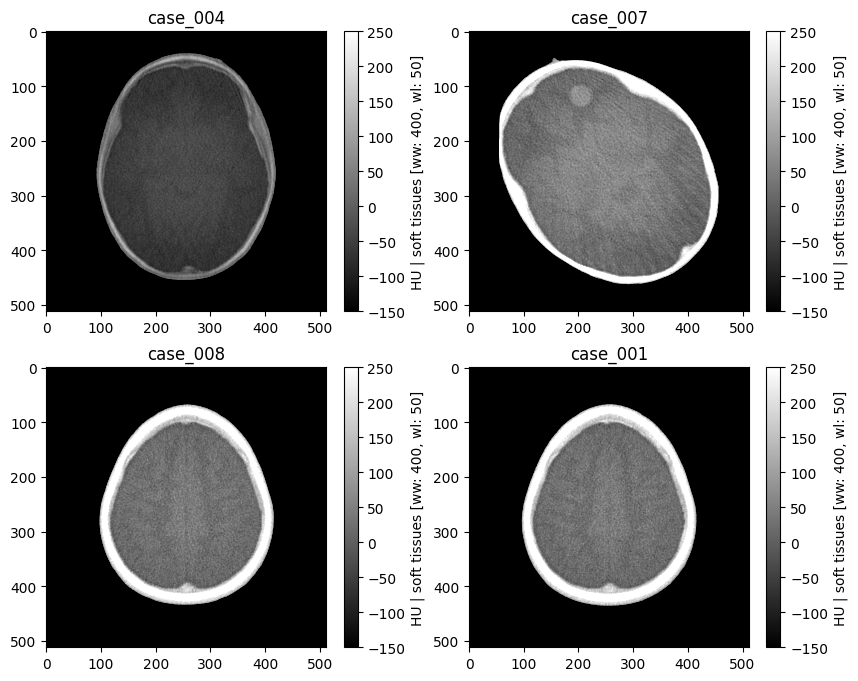

In [56]:
f, axs = plt.subplots(2,2, figsize=(10,8))
for case, ax in zip(metadata['name'].unique(), axs.flatten()):
    if metadata[metadata['name'] == case]['mask file'].isna().iloc[0]:
        z = 100
    else:
        z, x, y = get_lesion_coords(load_vol(metadata[metadata['name'] == case]['mask file']))
    browse_studies(metadata, case, slice_idx=z, f=f, ax=ax)

### Highlighting the lesion location with a bounding box

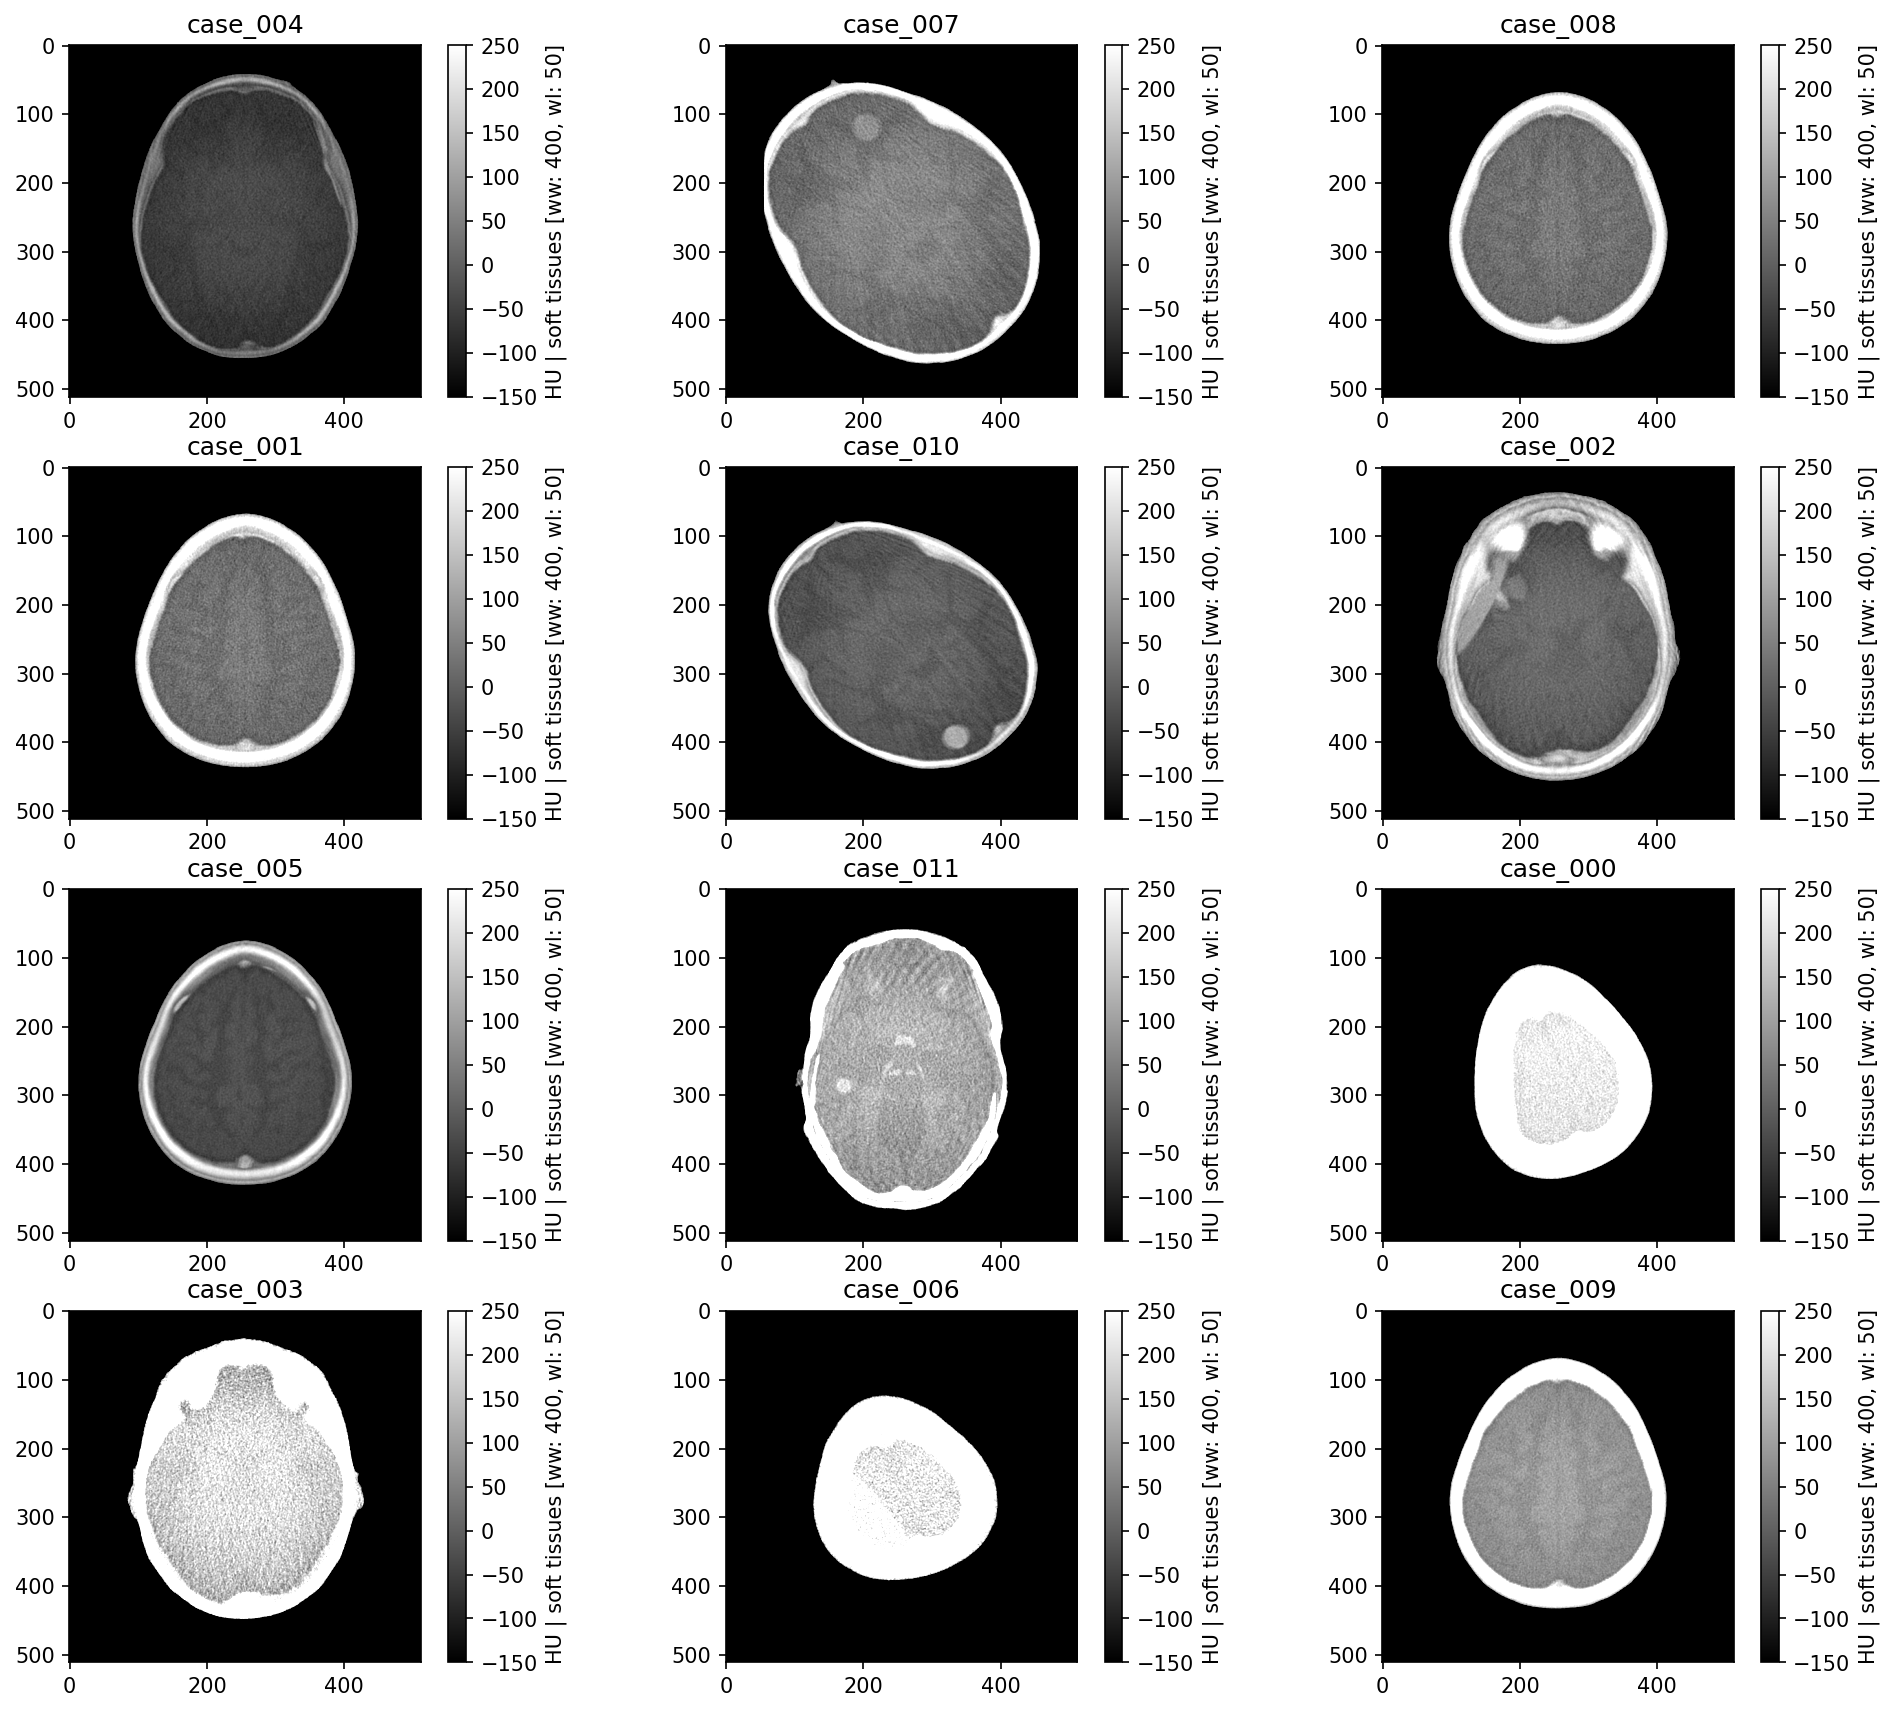

In [60]:
from matplotlib.patches import Rectangle 
nrows = 4
ncols = 3
f, axs = plt.subplots(nrows,ncols, figsize=(nrows*4,ncols*4+2), dpi=150)
for case, ax in zip(metadata['name'].unique(), axs.flatten()):
    if metadata[metadata['name'] == case]['mask file'].isna().iloc[0]:
        z = 100
    else:
        z, x, y = get_lesion_coords(load_vol(metadata[metadata['name'] == case]['mask file']))
    browse_studies(metadata, case, slice_idx=z, f=f, ax=ax)
    # width = 3*metadata[metadata['name'] == case]['radius'].unique()[0]
    # ax.add_patch(Rectangle((x-width/2, y-width/2), width=width, height=width, fc ='none', ec ='g', lw = 1))

### Highlighting the lesion location with a segmentation mask overlay

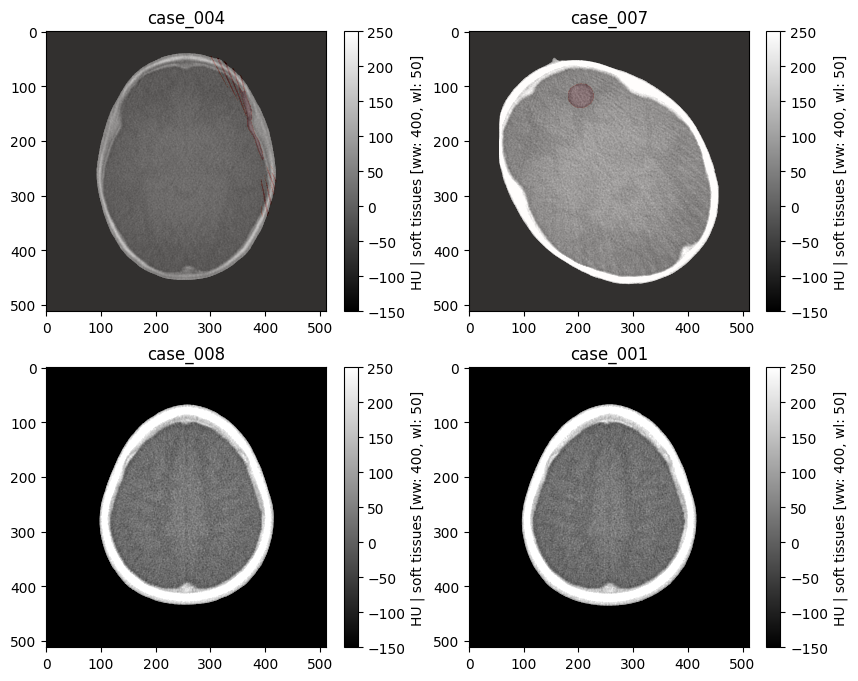

In [58]:
f, axs = plt.subplots(2,2, figsize=(10,8))
for case, ax in zip(metadata['name'].unique(), axs.flatten()):
    if not metadata[metadata['name'] == case]['mask file'].isna().iloc[0]:
        mask = load_vol(metadata[metadata['name'] == case]['mask file'])
        z, x, y = get_lesion_coords(mask)
    else:
         z = 100
    img = load_vol(metadata[metadata['name'] == case]['image file'])
    browse_studies(metadata, case, slice_idx=z, f=f, ax=ax)
    if not metadata[metadata['name'] == case]['mask file'].isna().iloc[0]:
        ax.imshow(mask[z] & (img[z]>-300), cmap='Reds', alpha=0.2)

## Reformated Views

In [59]:
from utils import scrollview
vol = load_vol(metadata[metadata['name']=='case_014']['image file'])
mask = load_vol(metadata[metadata['name']=='case_014']['mask file'])

vol.shape, mask.shape

ValueError: need at least one array to stack

In [ ]:
scrollview(vol)

In [ ]:
scrollview(vol.transpose(1,0,2)[:,::-1])

In [ ]:
scrollview(vol.transpose(2,0,1)[:, ::-1])

In [ ]:
plt.imshow(vol.sum(axis=1), cmap='gray')
plt.imshow(mask.sum(axis=1), cmap='Reds', alpha=0.1)

In [ ]:
metadata['lesion type'].unique()

In [ ]:
metadata[(metadata['lesion type'] == 'epidural') & (~metadata['name'].duplicated())].sort_values(by='lesion volume [mL]')

In [ ]:
metadata[(metadata['lesion type'] == 'subdural') & (~metadata['name'].duplicated())].sort_values(by='lesion volume [mL]')

In [ ]:
metadata[(metadata['lesion type'] == 'sphere') & (~metadata['name'].duplicated())].sort_values(by='lesion volume [mL]')

## Fig. 1 Plot Showing Dataset Labels 3 lesion types with masks

In [ ]:
from utils import ctshow

cases = ['case_017', 'case_008', 'case_014']
f, axs = plt.subplots(2, len(cases), dpi=150, tight_layout=True)
if axs.ndim < 2:
    axs = axs[:, None]

for idx, case in enumerate(cases):
    z = metadata[metadata['name'] == case]['center z'].iloc[0].astype(int)+1
    mask = read_dicom(metadata[metadata['name'] == case].iloc[z]['mask file'])
    img = read_dicom(metadata[metadata['name'] == case].iloc[z]['image file'])

    age =  metadata[metadata['name'] == case].iloc[z]['age'].astype(int)
    
    lesion_type = metadata[metadata['name'] == case].iloc[z]['lesion type']
    lesion_type = 'regular' if lesion_type == 'sphere' else lesion_type
    vol =  metadata[metadata['name'] == case].iloc[z]['lesion volume [mL]']
    contrast = metadata[metadata['name'] == case].iloc[z]['contrast']
    
    ctshow(img, fig=f, ax=axs[0, idx], window='soft tissues')
    axs[0, idx].set_title(f'{age} yrs')
    ctshow(img, fig=f, ax=axs[1, idx], window='soft tissues')
    axs[1, idx].imshow(mask & (img > 0), cmap='Reds', alpha=0.2)
    axs[1, idx].set_title(f'{lesion_type}\n{vol:2.1f} mL, {contrast} HU')

## Fig. 2 Plot Comparisons of Different kVp, mA, Recon Kernel

In [ ]:
metadata[(~metadata['name'].duplicated())].sort_values(by='mA')

In [ ]:
metadata[(~metadata['name'].duplicated())].sort_values(by='kVp')

## Fig 3. Pilot Study ROC curves with real and synthetic data